In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.linear_model import LassoCV, Lasso
from sklearn.model_selection import KFold, cross_val_score


gdf = gpd.read_file(r"../data/updated_data.geojson")

#fem_house_rate has been deleted because it is obvious that if fem_house_rate is high, ratio_fem_mal will be low
col_to_del_linear_model=['rip_code','reg_code','prov_code','prov_area_code', 'prov_type','geo_point_2d','urban_type','private_coverage','fem_house_rate']
# col_to_del_linear_model=['rip_code','reg_code','prov_code','prov_area_code', 'prov_type','geo_point_2d','urban_type','private_coverage']

gdf.drop(columns=col_to_del_linear_model,inplace=True)



In [80]:
# corr_xy = gdf['fem_empl_rate'].corr(gdf['empl_rate'])
# print(corr_xy)


gdf['ratio_fem_mal']=gdf['fem_empl_rate']/gdf['mal_empl_rate']
gdf['ratio_edu_rate']=gdf['fem_edu_rate']/gdf['male_edu_rate']

In [81]:
X=gdf.select_dtypes(include='number').drop(columns=['fem_empl_rate','mal_empl_rate','ratio_fem_mal','fem_edu_rate','male_edu_rate'])
y=gdf['ratio_fem_mal']

# X=gdf.select_dtypes(include='number').drop(columns=['fem_empl_rate','mal_empl_rate','fem_edu_rate','male_edu_rate'])
# y=gdf['fem_empl_rate']


# Correlation Part

In [82]:
import numpy as np

#THRESHOLD=0.9, each variable has been deleted one by one by keeping 'empl_rate' (because it's easy to interprate empl_rate)
col_to_drop=['other_per_capita_expenditure','inact_rate','adj_net_migration_rate','part_rate','unempl_rate']
# col_to_drop=['empl_rate', 'inact_rate', 'other_per_capita_expenditure', 'adj_net_migration_rate']

X.drop(columns=col_to_drop,inplace=True)

corr_matrix=X.corr()

upper_matrix = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

stacked=upper_matrix.stack()
best_pair = stacked.abs().idxmax()
best_corr_value = stacked.loc[best_pair]

print('best_pair',best_pair,'best_corr_value',best_corr_value)


best_pair ('young_neet', 'empl_rate') best_corr_value -0.899905224315081


In [83]:
#there is one missing value on ecec_diffusion variable
print(X.isna().sum())
X["ecec_diffusion"] = X["ecec_diffusion"].fillna(X["ecec_diffusion"].median())


population                            0
empl_growth                           0
service_empl_rate                     0
GDP                                   0
n_large_comp                          0
n_self_empl                           0
young_neet                            0
foreign_rate                          0
n_members_family                      0
elderly_in_care                       0
house_price                           0
fertility_rate                        0
first_birth_maternal_age              0
avg_children_per_woman                0
dependency_rate                       0
ageing_index                          0
net_migration_rate                    0
area_km2                              0
public_transport_supply               0
internet_coverage_rate                0
graduate_mobility_rate                0
green_m2_capita                       0
eco_urban_index                       0
per_capita_public_expenditure         0
ecec_participation                    0


In [84]:


selected_covariates=X.columns

X = X.to_numpy()
y = y.to_numpy()

print(y.shape)

# standardize predictors and the target
X_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X)

y_mean = y.mean()
y_std = y.std()
y_scaled = (y - y_mean) / y_std

n_obs, n_feat = X_scaled.shape
print(f"\nNumber of observations: {n_obs}, number of predictors: {n_feat}")


(107,)

Number of observations: 107, number of predictors: 38


# Frequentist Lasso (Credits : Chi)

Best alpha found: 0.0300

Mean CV R²: 0.815 ± 0.089
Mean CV MSE: 0.147 ± 0.081


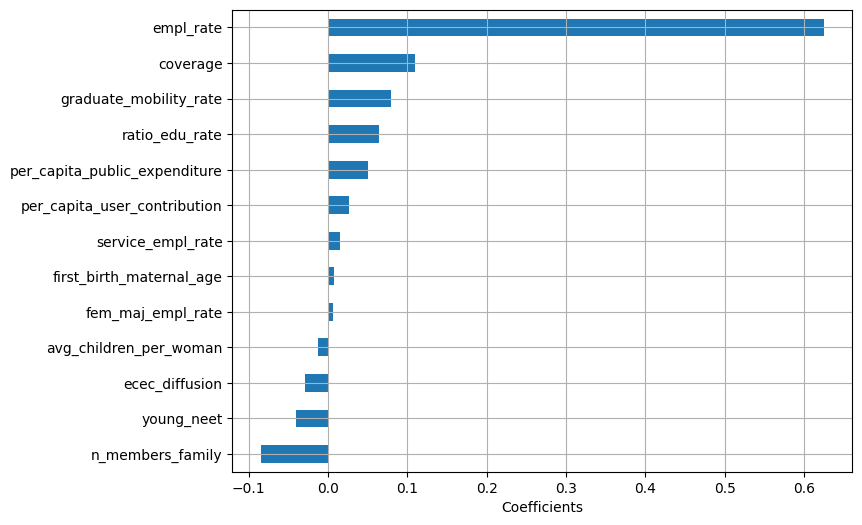

In [85]:


cv = KFold(n_splits=10, shuffle=True, random_state=42)
lasso_cv = LassoCV(cv=cv, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y_scaled)

print(f"Best alpha found: {lasso_cv.alpha_:.4f}")

lasso_final = Lasso(alpha=lasso_cv.alpha_)
lasso_final.fit(X_scaled, y_scaled)

coef = pd.Series(lasso_final.coef_, index=selected_covariates)
nonzero_coef = coef[coef != 0].sort_values(ascending=False)
# print("\nNon-zero coefficients (variables selected by Lasso):")
# print(nonzero_coef)

r2_scores = cross_val_score(lasso_final, X_scaled, y_scaled, cv=cv, scoring='r2')
mse_scores = -cross_val_score(lasso_final, X_scaled, y_scaled, cv=cv, scoring='neg_mean_squared_error')
print(f"\nMean CV R²: {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")
print(f"Mean CV MSE: {np.mean(mse_scores):.3f} ± {np.std(mse_scores):.3f}")

plt.figure(figsize=(8,6))
nonzero_coef.sort_values().plot(kind='barh')
# plt.title('Lasso-selected variables influencing ratio female/male employment rate')
plt.xlabel('Coefficients')
plt.grid(True)
plt.show()

/var/folders/y9/rry2kyrd4wlb4xwqx57mrs540000gn/T/ipykernel_69113/2884519301.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


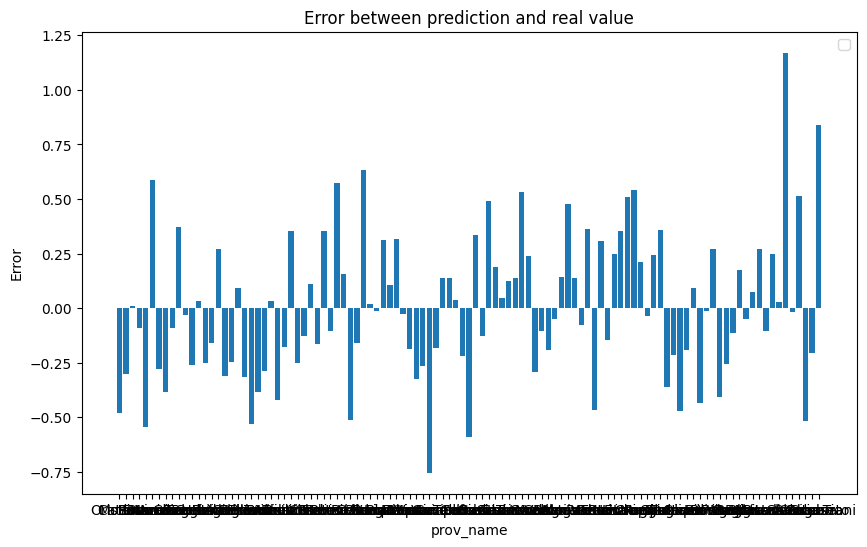

In [86]:
y_pred = lasso_final.predict(X_scaled)

Error=y_pred-y_scaled

# print(np.mean(Error**2))
# Graphique comparatif
plt.figure(figsize=(10,6))
# plt.boxplot(Error)
plt.bar(gdf["prov_name"],Error)
plt.xlabel("prov_name")
plt.ylabel("Error")
plt.title("Error between prediction and real value")
plt.legend()
plt.show()

# Bayes Lasso (Credits : Leo)

In [87]:
with pm.Model() as bl_model:
    X_data = pm.Data("X_data", X_scaled)
    y_data = pm.Data("y_data", y_scaled)

    lambda_ = pm.Gamma("lambda", alpha=0.1, beta=0.1)
    sigma = pm.HalfNormal("sigma", sigma=1.0)


    beta = pm.Laplace(
        "beta",
        mu=0.0,
        b=sigma / lambda_,
        shape=n_feat
    )


    mu = pm.math.dot(X_data, beta)

    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data)


    trace = pm.sample(
        draws=2000,
        tune=2000,
        target_accept=0.9,
        return_inferencedata=True,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lambda, sigma, beta]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/rich/live.py:256: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 37 seconds.


In [88]:
summary_beta = az.summary(trace, var_names=["beta"], hdi_prob=0.95)

summary_beta.index = selected_covariates

summary_beta["contains_zero"] = (
    (summary_beta["hdi_2.5%"] <= 0) &
    (summary_beta["hdi_97.5%"] >= 0)
)

# summary_beta["contains_zero"] = (
#     (summary_beta["hdi_5%"] <= 0) &
#     (summary_beta["hdi_95%"] >= 0)
# )

summary_beta = summary_beta.sort_values("mean", key=np.abs, ascending=False)

print(summary_beta[["mean", "hdi_2.5%", "hdi_97.5%", "contains_zero"]])
# print(summary_beta[["mean", "hdi_5%", "hdi_95%", "contains_zero"]])


                                     mean  hdi_2.5%  hdi_97.5%  contains_zero
empl_rate                           0.548     0.263      0.823          False
coverage                            0.108    -0.010      0.230           True
ratio_edu_rate                      0.095    -0.002      0.197           True
n_members_family                   -0.072    -0.200      0.031           True
graduate_mobility_rate              0.071    -0.060      0.232           True
young_neet                         -0.068    -0.202      0.051           True
ecec_diffusion                     -0.062    -0.157      0.020           True
per_capita_user_contribution        0.047    -0.050      0.171           True
per_capita_public_expenditure       0.044    -0.061      0.157           True
avg_children_per_woman             -0.037    -0.153      0.050           True
fem_maj_empl_rate                   0.031    -0.043      0.118           True
n_self_empl                        -0.028    -0.108      0.046  

/var/folders/y9/rry2kyrd4wlb4xwqx57mrs540000gn/T/ipykernel_69113/1335158891.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


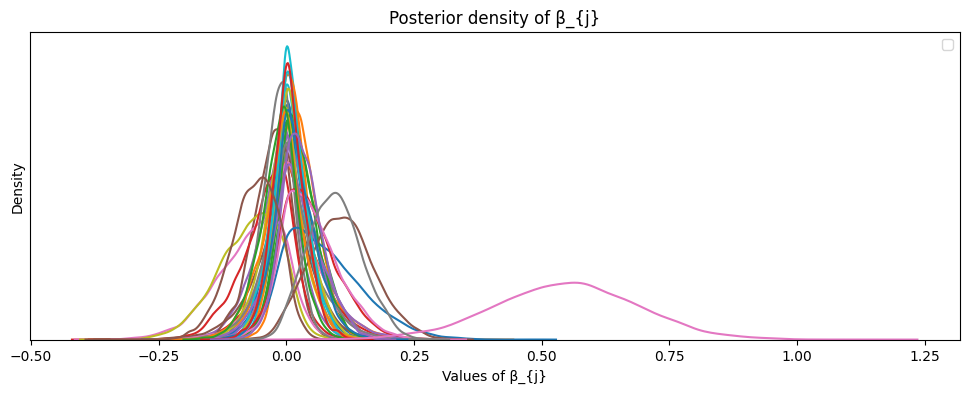

In [89]:
# az.rcParams["plot.max_subplots"] = 100   
# az.plot_trace(trace, compact=False)
# az.plot_trace(trace, var_names=["beta"])
# plt.tight_layout()

import matplotlib.pyplot as plt
import numpy as np

beta_samples = trace.posterior["beta"].stack(samples=("chain", "draw")).values

plt.figure(figsize=(12,4))

for i in range(beta_samples.shape[0]):
    # if (selected_covariates[i] in ['empl_rate','coverage','ratio_edu_rate','n_members_family','graduate_mobility_rate']):
    #     sns.kdeplot(beta_samples[i, :],label=selected_covariates[i])
    # else:
        sns.kdeplot(beta_samples[i, :])

plt.legend()
plt.title("Posterior density of β_{j}")
plt.xlabel("Values of β_{j}")
plt.yticks([])     
plt.gca().tick_params(axis='y', length=0)

plt.show()


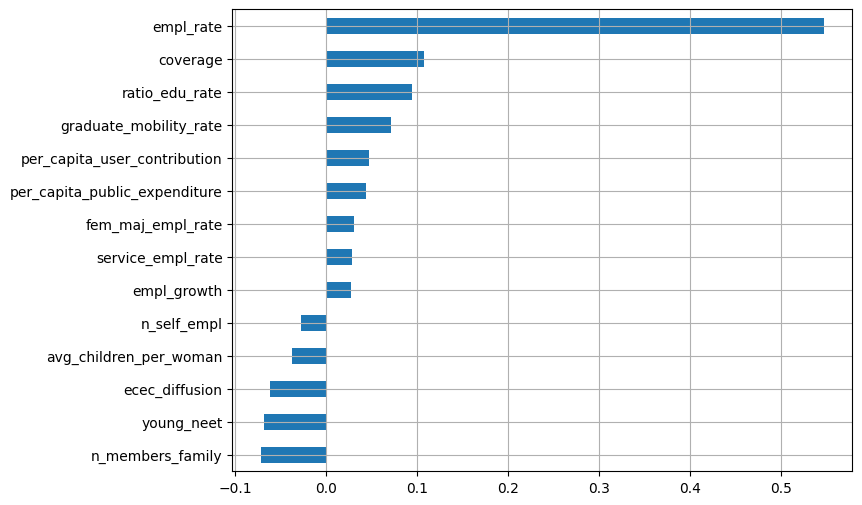

In [90]:
important_covariates=summary_beta[summary_beta["mean"].abs()>0.025]['mean']

plt.figure(figsize=(8,6))
important_covariates.sort_values().plot(kind='barh')
plt.grid(True)
plt.show()